In [2]:
import numpy as np                  # to do math
from astropy.io import fits         # handline .fits files
import pandas as pd                 # table format
import os                           # universal os
from astroquery.sdss import SDSS    # to query SDSS spectra
import matplotlib.pyplot as plt     # for plotting

# Parent sample

We are using a parent sample of ~2 million galaxies from SDSS-IV/[eBOSS](https://www.sdss4.org/surveys/eboss/) to identify VMS candidates

In [3]:
data_folder_name = 'data'  # folder containing the data file
filename = 'eboss_dr17_summary_odtrim8_v1.fit'  # data file

# accessing file from current directory
file_path = os.path.join('..', data_folder_name, filename)
file_path

'../data/eboss_dr17_summary_odtrim8_v1.fit'

To access the data, we will use `astropy` `fits` functions. Once opened, our data is stored in a "FITS table". The table header has info on the dimensions (# of rows and columns) and the column names. 

In [4]:
# hdu: "header data unit"
# contains information on the format and contents of our fits file
hdu = fits.open(file_path)

# displaying the header of our fits file
hdu[1].header

XTENSION= 'BINTABLE'           /Binary table written by MWRFITS v1.11           
BITPIX  =                    8 /Required value                                  
NAXIS   =                    2 /Required value                                  
NAXIS1  =                  732 /Number of bytes per row                         
NAXIS2  =              1893695 /Number of rows                                  
PCOUNT  =                    0 /Normally 0 (no varying arrays)                  
GCOUNT  =                    1 /Required value                                  
TFIELDS =                  107 /Number of columns in table                      
COMMENT                                                                         
COMMENT  *** End of mandatory fields ***                                        
COMMENT                                                                         
COMMENT                                                                         
COMMENT  *** Column names **

As you can see, this table has a LOT of columns... to make things simple, we will extract the columns that we need and ignore the rest.

The main column values we are interested in are 

The strength ("equivalent width") of spectral emission lines:

- `H_ALPHA_EW`
- `H_BETA_EW`
- `HEII_4686_EW`

and their associated signal-to-noise ratios:

- `H_ALPHA_FLUX`  /  `H_ALPHA_FLUX_ERR`
- `H_BETA_FLUX`  /  `H_BETA_FLUX_ERR`
- `HEII_4686_FLUX`  /  `HEII_4686_FLUX_ERR`

We will also save basic stuff about these eBOSS sources, such as redshift and identification information.

In [5]:
# ... this cell might take a minute to run ...

# initializing a DataFrame
eBOSS_catalog = pd.DataFrame()

# ------- setting the columns and rows for our table --------

# general info on objects
eBOSS_catalog['PLATE'] = list(hdu[1].data['PLATE'])                      
eBOSS_catalog['MJD'] = list(hdu[1].data['MJD'])  
eBOSS_catalog['FIBER'] = list(hdu[1].data['FIBER'])     
# PLATE, MJD, and FIBER numbers combined into an identification string
eBOSS_catalog['PMF_STRING'] = list(hdu[1].data['PMF_STRING'])    
# redshift of galaxy
eBOSS_catalog['Z'] = list(hdu[1].data['Z'])  
eBOSS_catalog['Z_ERR'] = list(hdu[1].data['Z_ERR'])  
# coordinates of galaxy 
eBOSS_catalog['RA'] = list(hdu[1].data['RA'])                                         
eBOSS_catalog['DEC'] = list(hdu[1].data['DEC']) 

# revelant spectral line measurements
eBOSS_catalog['H_ALPHA_EW'] = list(hdu[1].data['H_ALPHA_EW']) 
eBOSS_catalog['H_BETA_EW'] = list(hdu[1].data['H_BETA_EW']) 
eBOSS_catalog['HEII_4686_EW'] = list(hdu[1].data['HEII_4686_EW']) 
# and their associated SNR
eBOSS_catalog['H_ALPHA_SNR'] = list( np.array(hdu[1].data['H_ALPHA_FLUX']) / np.array(hdu[1].data['H_ALPHA_FLUX_ERR']) )
eBOSS_catalog['H_BETA_SNR'] = list( np.array(hdu[1].data['H_BETA_FLUX']) / np.array(hdu[1].data['H_BETA_FLUX_ERR']) )
eBOSS_catalog['HEII_4686_SNR'] = list( np.array(hdu[1].data['HEII_4686_FLUX']) / np.array(hdu[1].data['HEII_4686_FLUX_ERR']) )

# --------------------------------------------------------------

# masking out null measurements
null_measurements = (
    (eBOSS_catalog['H_ALPHA_EW'] != -999) &    # values which represent unsuccessful measurement of the line
    (eBOSS_catalog['H_BETA_EW'] != -999) &     # ''
    (eBOSS_catalog['HEII_4686_EW'] != -999)    # ''
)

# displaying our table
eBOSS_catalog = eBOSS_catalog[null_measurements]
eBOSS_catalog

,PLATE,MJD,FIBER,PMF_STRING,Z,Z_ERR,RA,DEC,H_ALPHA_EW,H_BETA_EW,HEII_4686_EW,H_ALPHA_SNR,H_BETA_SNR,HEII_4686_SNR
1,3586,55181,6,03586-55181-0006,0.533117,0.000141,9.409157,-0.250058,2.060369,0.239696,0.000000,0.965153,0.477673,0.000000
2,3586,55181,7,03586-55181-0007,0.474463,0.000134,9.360470,-0.212842,0.000000,0.510076,0.000000,0.000000,1.397723,0.000000
3,3586,55181,8,03586-55181-0008,0.489547,0.000159,9.351932,-0.159622,2.960478,0.000000,0.000000,2.957982,0.000000,0.000000
4,3586,55181,9,03586-55181-0009,0.489842,0.000225,9.452027,-0.105271,1.556909,0.766571,0.000000,1.221130,0.854249,0.000000
5,3586,55181,10,03586-55181-0010,0.464648,0.000173,9.477723,-0.131829,0.000000,0.620501,1.071623,0.000000,1.758459,1.217315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1893687,12547,58928,981,12547-58928-0981,0.089286,0.000015,141.047762,2.389383,9.507236,2.125244,0.000000,47.871681,11.996006,0.000000
1893691,12547,58928,986,12547-58928-0986,0.391036,0.000069,140.956507,2.087150,0.595381,0.788362,0.000000,0.877126,1.863517,0.000000
1893692,12547,58928,988,12547-58928-0988,0.024241,0.000021,140.953350,2.107938,114.652946,26.197693,11.339873,21.968134,7.062411,2.965083
1893693,12547,58928,991,12547-58928-0991,0.535690,0.000092,140.905378,2.599161,34.857849,8.350409,0.805497,4.011547,7.710182,1.069995


Now we have a table with the data that we care about! This is our parent sample from the eBOSS catalog. The number of rows in this table is the number of galaxies in the sample... there are a lot ! Next we will take some steps to cut this parent sample down into a subsample of galaxies that are VMS candidates.

# Subsample of galaxies with high ionization

Part of the difficulty in finding VMS is due to their short lifespan. They are present for a much shorter time than lower-mass stars. Thus, they are best located in star clusters that have recently formed (we call these "young" star clusters). Young stars emit A LOT of ionizing photons. 

To isolate galaxies with young star clusters, we will cut our parent sample into a subsample of galaxies with high ionization. 

In [6]:
high_ion_mask = (

    # high ionization
    (eBOSS_catalog['H_BETA_EW'] > 100) &
    # requiring signal-to-noise ratio >= 10
    (eBOSS_catalog['H_BETA_SNR'] >= 10) 
)

high_ion_eBOSS = eBOSS_catalog[high_ion_mask]
len(high_ion_eBOSS)  # let's see the size of this new sample

1386

Now lets inspect the spectra for these high-ionization galaxies ... for this, we will use the `astroquery` tool.

In [7]:
number_of_gal_to_inspect = 5                                     # (you can change this value)
inspect_sample = high_ion_eBOSS.iloc[:number_of_gal_to_inspect]  # slicing our subsample
inspect_sample

,PLATE,MJD,FIBER,PMF_STRING,Z,Z_ERR,RA,DEC,H_ALPHA_EW,H_BETA_EW,HEII_4686_EW,H_ALPHA_SNR,H_BETA_SNR,HEII_4686_SNR
2595,3590,55201,554,03590-55201-0554,0.344603,0.000014,11.001109,0.790189,632.756653,129.946548,3.753939,51.275002,74.241043,2.097736
17627,3662,55182,546,03662-55182-0546,0.205231,0.000013,112.402841,37.085000,424.490234,155.580231,2.809634,39.868034,20.860123,1.420017
18250,3663,55176,766,03663-55176-0766,0.076291,0.000011,114.085117,45.979487,582.441406,120.043915,3.159346,75.502991,46.597088,2.879046
20335,3667,55186,806,03667-55186-0806,0.421750,0.000011,115.844578,37.422689,701.575073,106.982895,1.809964,64.058449,47.220814,1.560171
22069,3670,55480,196,03670-55480-0196,0.068112,0.000010,117.144778,38.750600,728.617188,138.177734,1.710456,78.052818,43.722092,2.022614


In [8]:
# ... this cell might take a minute to run ...

rest_frame_wavelengths = []
rest_frame_flux_densities = []
rest_frame_flux_density_errs = []

for i in range(number_of_gal_to_inspect):

    # saving basic info for this galaxy
    data = inspect_sample.iloc[i]
    plate = int(data['PLATE'])
    mjd   = int(data['MJD'])
    fiber = int(data['FIBER'])
    key = data['PMF_STRING']
    z = data['Z']

    # try to query spectra from SDSS archive
    try:

        # query
        spec = SDSS.get_spectra(plate=plate,mjd=mjd,fiberID=fiber)

        if spec is not None:

            hdu = spec[0]  # header-data unit (hdu)

            # ----------- saving spectral data ------------

            # flux
            flux_density_factor = hdu[1].data['flux']             # 10^-17 * [ergs / s / cm^2 / A]
            flux_density = 10**(-17) * flux_density_factor        # [ergs / s / cm^2 / A]
            rest_flux_density = flux_density * (1+z)              # convert spectrum from observed frame to rest frame using the object's redshift
            rest_frame_flux_densities.append(rest_flux_density)   # ... saving these data

            # flux error
            ivar = hdu[1].data['ivar']
            flux_density_err = np.zeros_like(flux_density)
            good = ivar > 0                                             # avoid dividing by zero
            flux_density_err[good] = 1e-17 / np.sqrt(ivar[good])
            rest_flux_density_err = flux_density_err * (1+z)            # convert spectrum from observed frame to rest frame using the object's redshift
            rest_frame_flux_density_errs.append(rest_flux_density_err)  # ... saving these data

            # wavelength
            log_wav = hdu[1].data['loglam']
            wavelength = 10**log_wav                         # [A]
            rest_wavelength = wavelength / (1+z)             # convert spectrum from observed frame to rest frame using the object's redshift
            rest_frame_wavelengths.append(rest_wavelength)   # ... saving these data

            # ----------------------------------------------

            print(f'successfully saved spectrum for {key}')

    # if unable to find spectra, give exception
    except Exception as e:
        print(f"Failed to retrieve spectrum for {key}: {e}")

print(f'\nquery complete for {number_of_gal_to_inspect} galaxies')


successfully saved spectrum for 03590-55201-0554
successfully saved spectrum for 03662-55182-0546
successfully saved spectrum for 03663-55176-0766
successfully saved spectrum for 03667-55186-0806
successfully saved spectrum for 03670-55480-0196

query complete for 5 galaxies


Below, we plot the spectra for the galaxies we queried from our subsample.

In [9]:
# some spectral features we will highlight in the plots
H_alpha_str = 'H-alpha'           
H_alpha_rest_wavelength = 6562.8   # rest-frame wavlength in Angstroms
H_beta_str = 'H-beta'              
H_beta_rest_wavelength = 4862.7   # rest-frame wavlength in Angstroms

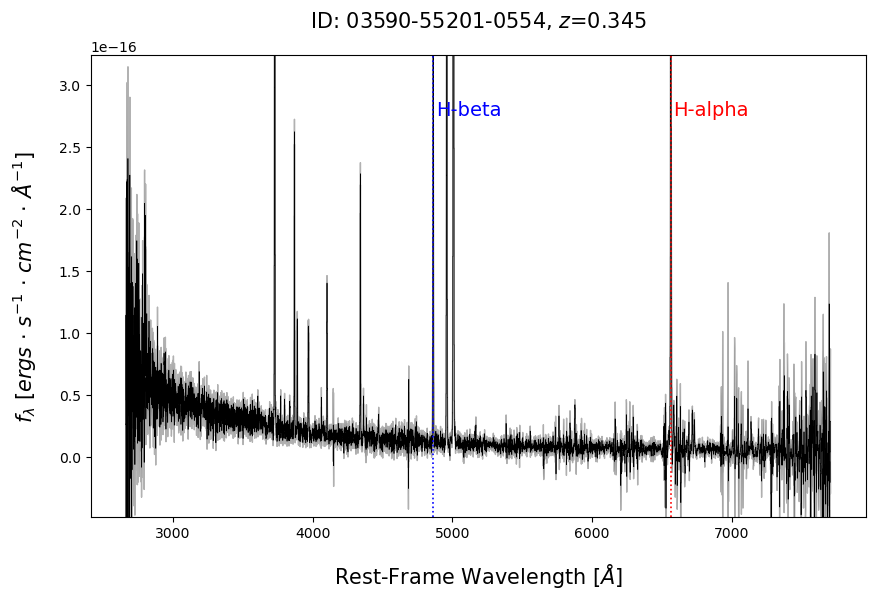

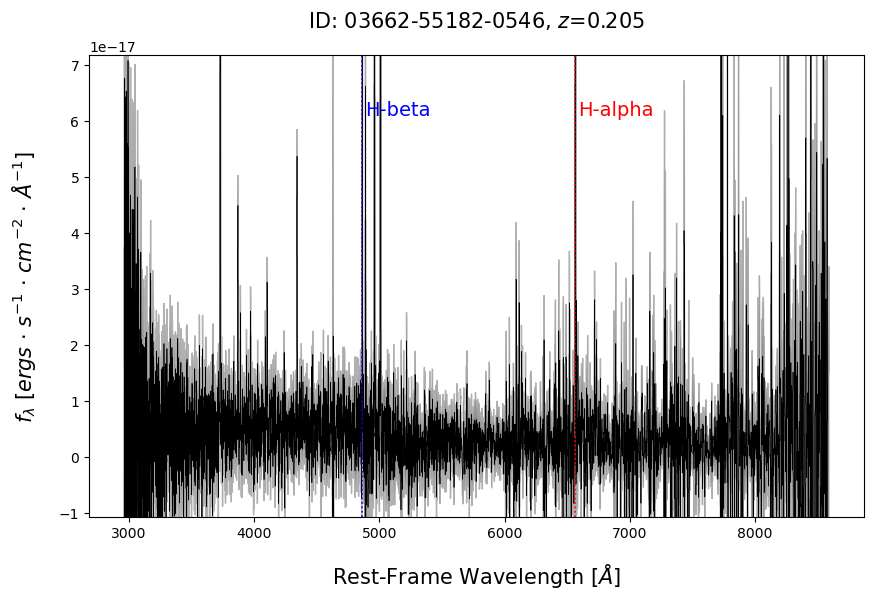

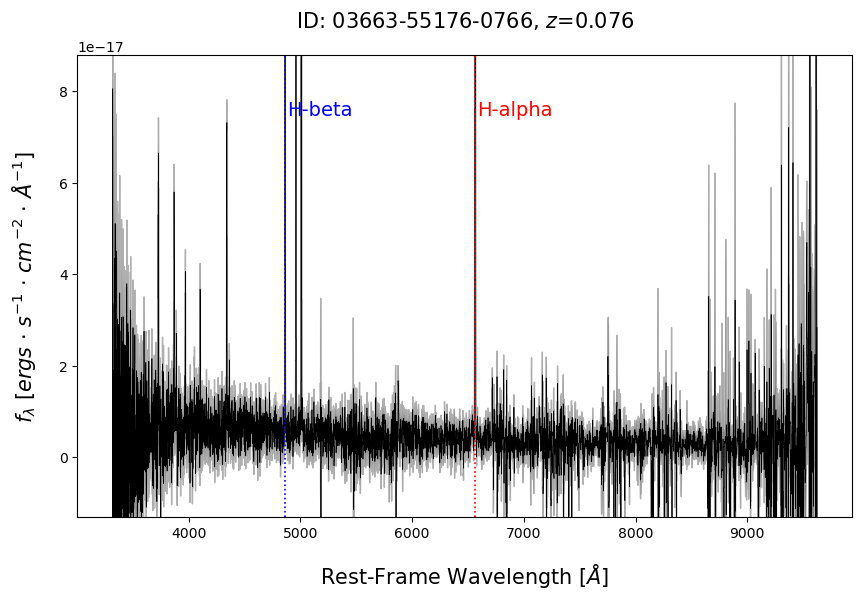

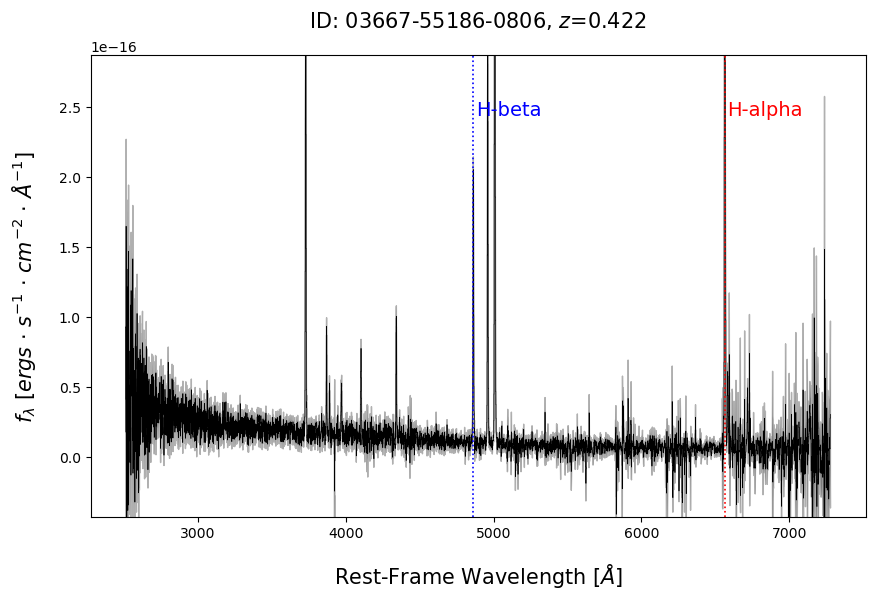

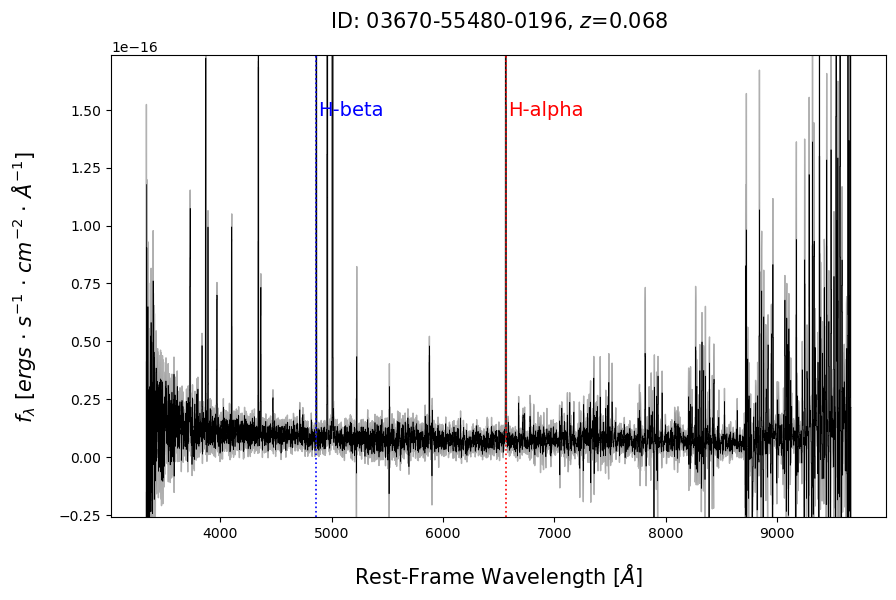

In [10]:
for i in range(number_of_gal_to_inspect):

    # saving basic info for this galaxy
    data = inspect_sample.iloc[i]
    plate = int(data['PLATE'])
    mjd   = int(data['MJD'])
    fiber = int(data['FIBER'])
    key = data['PMF_STRING']
    z = data['Z']

    # compute the median flux value (which approximates the continuum level emission)
    median_flux = np.median(rest_frame_flux_densities[i])

    # ~~~~~~~~~~~~~~ try updating the lower and upper factors ~~~~~~~~~~~~~~
    lower_y_lim = median_flux * -3
    upper_y_lim = median_flux * 20
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

    # initializing our figure
    plt.figure(figsize=(10,6))

    # labeling our axes
    plt.title(f"ID: {key}, $z$={z:.3f}",fontsize=15, pad=20)
    plt.xlabel(r'Rest-Frame Wavelength [$\AA$]', fontsize=15, labelpad=15)
    plt.ylabel(r'$f_{\lambda}$ [$ergs$ $\cdot$ $s^{-1}$ $\cdot$ $cm^{-2}$ $\cdot$ $\AA^{-1}$]', fontsize=15, labelpad=15)

    # main spectral data
    plt.step(rest_frame_wavelengths[i], rest_frame_flux_densities[i], where='mid', color='black', linewidth=0.5)

    # flux errors shown by shaded region
    upper = rest_frame_flux_densities[i] + rest_frame_flux_density_errs[i]
    lower = rest_frame_flux_densities[i] - rest_frame_flux_density_errs[i]
    plt.fill_between(rest_frame_wavelengths[i], lower, upper, color='black', alpha=0.3)

    # indicate where the our line of interest is located
    plt.axvline(H_alpha_rest_wavelength, color='red', linestyle='dotted', linewidth=1.2)
    plt.text(x=H_alpha_rest_wavelength + 20, y=upper_y_lim * 0.85, s=H_alpha_str, fontsize=14, color='red')
    plt.axvline(H_beta_rest_wavelength, color='blue', linestyle='dotted', linewidth=1.2)
    plt.text(x=H_beta_rest_wavelength + 20, y=upper_y_lim * 0.85, s=H_beta_str, fontsize=14, color='blue')

    # apply scaling factors to y-axis
    plt.ylim(lower_y_lim, upper_y_lim)

    # saving and displaying figure
    fig_name = f'{key}_spectrum.png'  # name the figure
    file_path = os.path.join('..', 'plots', fig_name)
    plt.savefig(file_path, dpi=500, bbox_inches='tight')  # save the figure !
    plt.show()

It also might be interesting to manually input the galaxy's ID (the `PMF_STRING` which contains numbers for the `PLATE`, `MJD`, and `FIBER`) into [SkyServer SDSS](https://skyserver.sdss.org/dr19/VisualTools/quickobj?plate=03615&mjd=55445&fiber=0570).

This online tool allows you to see an image of the galaxy and gives more info on its spectral features!

In [ ]:
# saving this high-ionization subsample for future reference
high_ion_eBOSS.to_csv('../subsamples/high_ionization_eBOSS.csv', index=False)